In [1]:
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [3]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA version PyTorch was built with: {torch.version.cuda}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Compute Capability: {torch.cuda.get_device_capability(0)}")

PyTorch version: 2.10.0+cu128
CUDA version PyTorch was built with: 12.8
GPU Name: NVIDIA GeForce RTX 5070
GPU Compute Capability: (12, 0)


In [4]:
import kagglehub
import os
# -------------------- Download dataset --------------------
print("Downloading dataset...")
path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print("Path to dataset files:", path)

# On Windows, the path might have backslashes; ensure it's a string
train_dir = os.path.join(path, "seg_train", "seg_train")
test_dir = os.path.join(path, "seg_test", "seg_test")

c:\Users\belw2\Desktop\ALL\ML && DL\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\belw2\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2


# --- 1.1 Define Paths and Transformations ---

In [5]:
import torch
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import os


# The path variable is from the previous cell where you downloaded the data
train_dir = os.path.join(path, "seg_train", "seg_train")
test_dir = os.path.join(path, "seg_test", "seg_test")
pred_dir = os.path.join(path, "seg_pred", "seg_pred")

# Define transformations for the training, validation, and testing sets
IMG_SIZE = 150
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(IMG_SIZE),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(IMG_SIZE),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}




# --- 1.2 Create Datasets and DataLoaders ---

In [7]:
# 1. #Crank up the batch size! 32 is way too small for an RTX 5070.
# Try 128 or 256. If you get a CUDA Out of Memory error, step it down.
BATCH_SIZE = 128 

# 2. Determine how many CPU cores to dedicate to data loading.
# Usually, 4 or 8 is a good sweet spot for Windows.
NUM_WORKERS = 4 

image_datasets = {
    'train': datasets.ImageFolder(train_dir, data_transforms['train']),
    'test': datasets.ImageFolder(test_dir, data_transforms['test'])
}

dataloaders = {
    'train': DataLoader(
        image_datasets['train'], 
        batch_size=BATCH_SIZE, 
        shuffle=True,
        num_workers=NUM_WORKERS, # Parallelize data augmentation on CPU
        pin_memory=True          # Speed up the RAM-to-VRAM transfer
    ),
    'test': DataLoader(
        image_datasets['test'], 
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'test']}
class_names = image_datasets['train'].classes
num_classes = len(class_names)

print(f"Classes: {class_names}")
print(f"Number of training images: {dataset_sizes['train']}")
print(f"Number of testing images: {dataset_sizes['test']}")

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Number of training images: 14034
Number of testing images: 3000


# --- 2. Define the CNN Model ---

In [8]:

# Using a pre-trained model (ResNet18) for better performance
model = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

# --- 3. Train the Model ---

In [9]:

import time
import copy

def train_model(model, criterion, optimizer, num_epochs=10):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    train_losses, test_losses = [], []
    train_accs, test_accs = [], []

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'test']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            
            if phase == 'train':
                train_losses.append(epoch_loss)
                train_accs.append(epoch_acc.item())
            else:
                test_losses.append(epoch_loss)
                test_accs.append(epoch_acc.item())

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # deep copy the model
            if phase == 'test' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best Test Acc: {best_acc:4f}')

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model, train_losses, test_losses, train_accs, test_accs

model, train_losses, test_losses, train_accs, test_accs = train_model(model, criterion, optimizer, num_epochs=10)

Epoch 0/9
----------
train Loss: 0.6938 Acc: 0.7508
test Loss: 0.3159 Acc: 0.8867

Epoch 1/9
----------
train Loss: 0.3603 Acc: 0.8686
test Loss: 0.2618 Acc: 0.9033

Epoch 2/9
----------
train Loss: 0.3175 Acc: 0.8840
test Loss: 0.2332 Acc: 0.9187

Epoch 3/9
----------
train Loss: 0.3009 Acc: 0.8891
test Loss: 0.2258 Acc: 0.9160

Epoch 4/9
----------
train Loss: 0.2880 Acc: 0.8954
test Loss: 0.2180 Acc: 0.9217

Epoch 5/9
----------
train Loss: 0.2729 Acc: 0.9037
test Loss: 0.2087 Acc: 0.9277

Epoch 6/9
----------
train Loss: 0.2608 Acc: 0.9047
test Loss: 0.2040 Acc: 0.9263

Epoch 7/9
----------
train Loss: 0.2544 Acc: 0.9067
test Loss: 0.2041 Acc: 0.9260

Epoch 8/9
----------
train Loss: 0.2539 Acc: 0.9062
test Loss: 0.2017 Acc: 0.9270

Epoch 9/9
----------
train Loss: 0.2352 Acc: 0.9134
test Loss: 0.2041 Acc: 0.9267

Training complete in 4m 40s
Best Test Acc: 0.927667


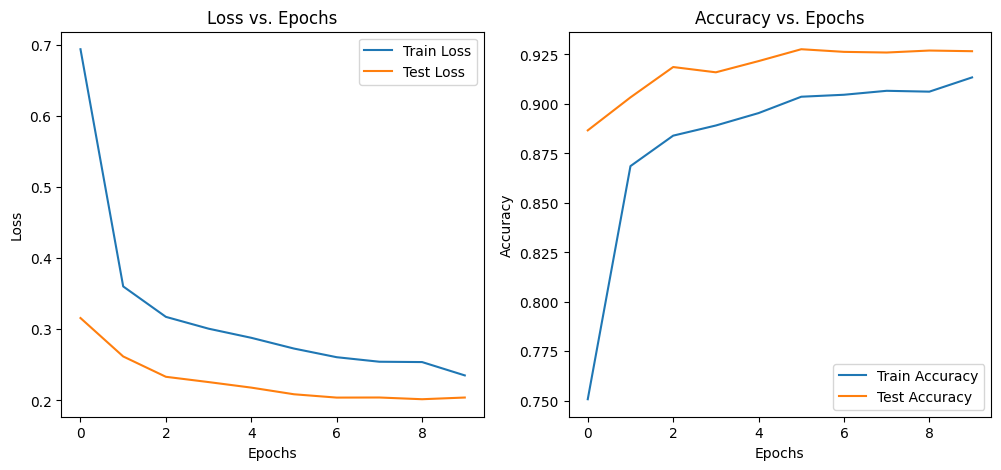

In [10]:
# --- 4. Plot Loss and Accuracy ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title('Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(test_accs, label='Test Accuracy')
plt.title('Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

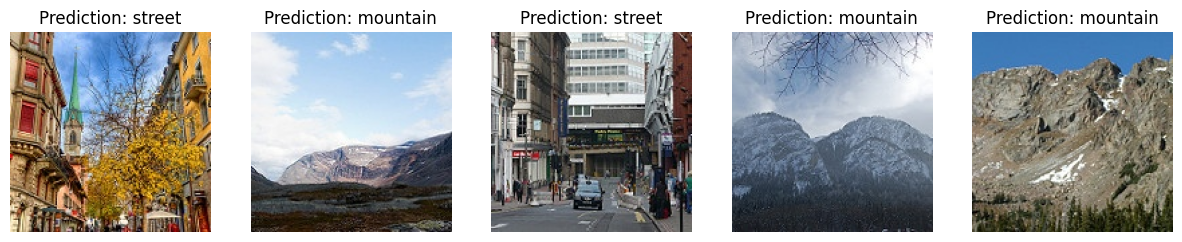

In [ ]:
# --- 5. Make Predictions ---
from PIL import Image
import random
import os

def predict_image(image_path, model, class_names):
    image = Image.open(image_path)
    # Apply the same transformations as the test set
    image = data_transforms['test'](image).unsqueeze(0)
    image = image.to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(image)
        _, predicted = torch.max(outputs, 1)
    
    return class_names[predicted[0]]

# Get a list of images in the prediction folder
pred_images = [os.path.join(pred_dir, f) for f in os.listdir(pred_dir) if os.path.isfile(os.path.join(pred_dir, f))]

# Determine the number of images to display
num_to_display = min(len(pred_images), 10)
if num_to_display > 0:
    display_images = random.sample(pred_images, num_to_display)

    # Predict and display the selected images
    plt.figure(figsize=(20, 8))
    for i, image_path in enumerate(display_images):
        prediction = predict_image(image_path, model, class_names)
        image = Image.open(image_path)
        
        # Adjust subplot layout if displaying fewer than 10 images
        cols = 5
        rows = (num_to_display + cols - 1) // cols
        plt.subplot(rows, cols, i + 1)
            
        plt.imshow(image)
        plt.title(f"Prediction: {prediction}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No images found in the prediction directory.")